# XGBoost + SHAP 분석

1. 데이터 로드 및 전처리
2. XGBoost 학습
3. 모델 성능 평가
4. SHAP 분석 (전체/개별)
5. 중요도 낮은 변수 제거 → 재학습 → 성능 비교

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb
import shap

BASE = Path('..').resolve()
SEED = 42
print('로드 완료')

로드 완료


## 1. 데이터 로드 및 피처 설정

In [3]:
df = pd.read_csv(
    BASE / 'data/02_interim/260506_feature_engineering/promotion_0_membership_v3.csv',
    encoding='utf-8-sig'
)
print(f'shape: {df.shape}')

# 모델링 제외 컬럼
EXCLUDE = [
    'USER_KEY','product_code','payment_device','device_group',
    'gender','reg_date','end_date','age_group',
    'reg_hour',  # reg_hour_group으로 대체
    'is_repurchase',  # 타겟
]
EXCLUDE = [c for c in EXCLUDE if c in df.columns]

# 문자열 컬럼 인코딩
from sklearn.preprocessing import LabelEncoder
for col in df.select_dtypes(include='object').columns:
    if col not in EXCLUDE:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

FEATURES = [c for c in df.columns if c not in EXCLUDE]
TARGET   = 'is_repurchase'

X = df[FEATURES].fillna(0)
y = df[TARGET]

print(f'피처 수: {len(FEATURES)}개')
print(f'이탈률: {(1-y.mean())*100:.1f}%')

shape: (7323, 59)
피처 수: 49개
이탈률: 30.2%


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

spw = (y_train==0).sum() / (y_train==1).sum()
print(f'scale_pos_weight: {spw:.2f}')

Train: (5858, 49)  |  Test: (1465, 49)
scale_pos_weight: 0.43


## 2. XGBoost 학습

In [5]:
model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print(f'최적 트리 수: {model.best_iteration}')

최적 트리 수: 372


## 3. 모델 성능 평가

AUC-ROC : 0.6516
F1 Score: 0.7827

              precision    recall  f1-score   support

       이탈(0)       0.48      0.41      0.44       443
      재구매(1)       0.76      0.81      0.78      1022

    accuracy                           0.69      1465
   macro avg       0.62      0.61      0.61      1465
weighted avg       0.68      0.69      0.68      1465



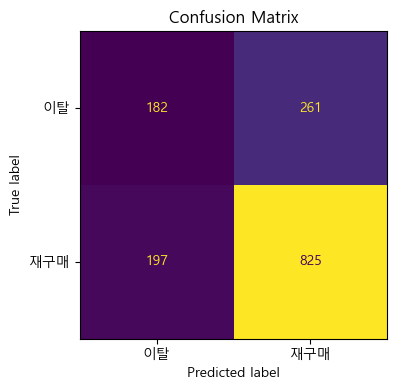

In [6]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f'AUC-ROC : {roc_auc_score(y_test, y_proba):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['이탈(0)','재구매(1)']))

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['이탈','재구매']).plot(ax=ax, colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## 4. SHAP 분석

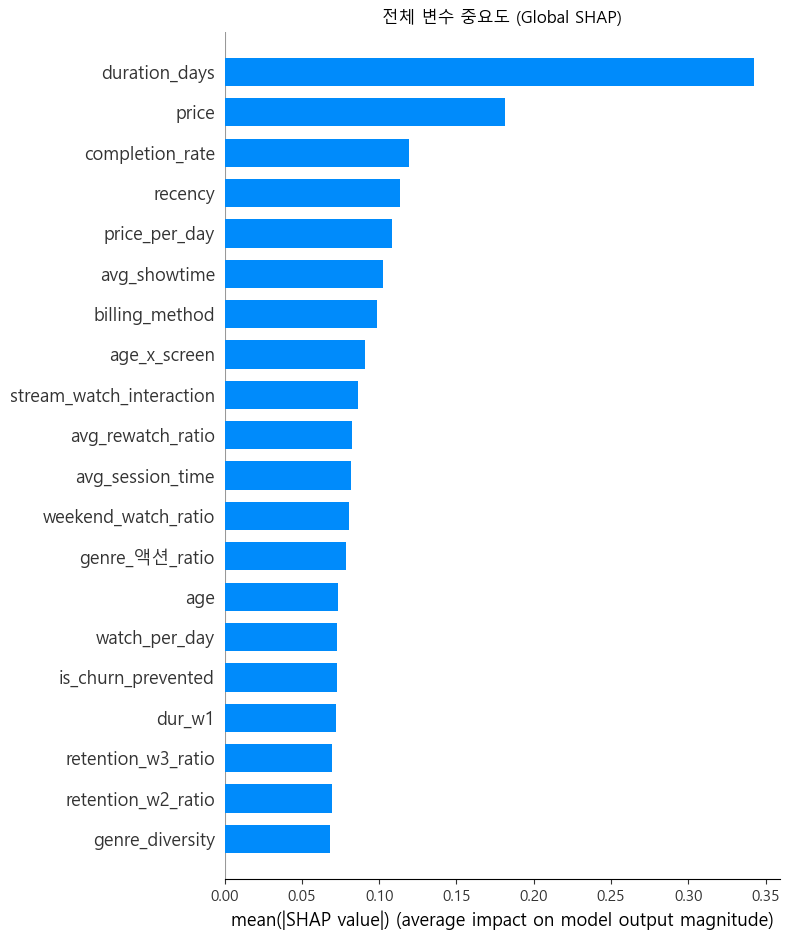

In [7]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 4-1. 전체 변수 중요도 (bar)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('전체 변수 중요도 (Global SHAP)')
plt.tight_layout()
plt.show()

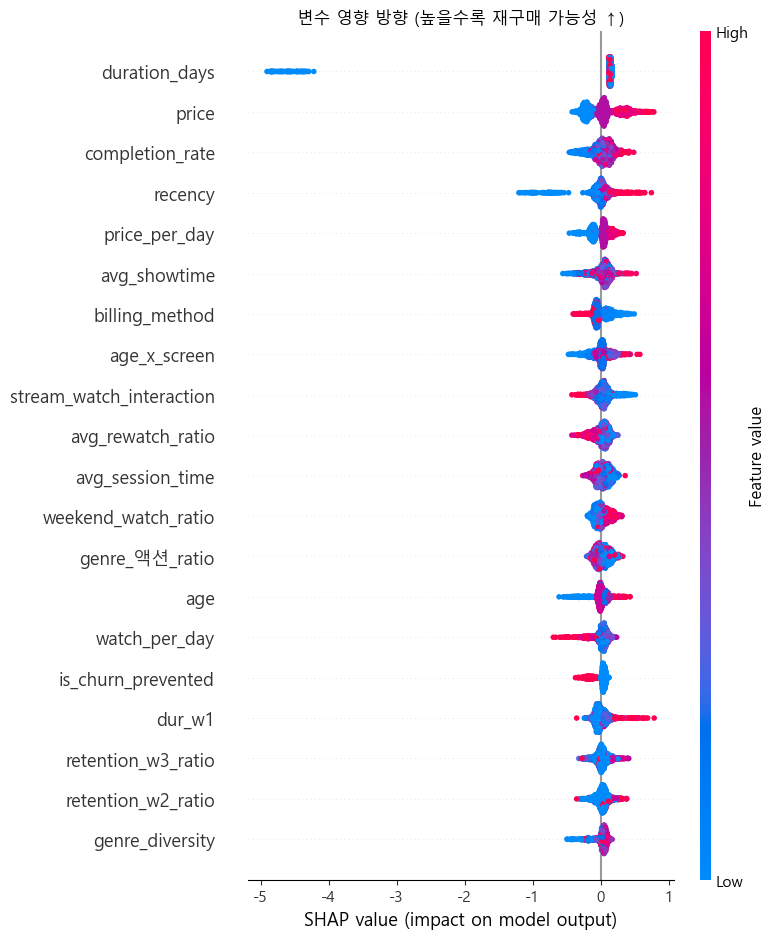

In [8]:
# 4-2. Beeswarm (방향 포함)
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('변수 영향 방향 (높을수록 재구매 가능성 ↑)')
plt.tight_layout()
plt.show()

In [9]:
# SHAP 중요도 테이블
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    '변수': FEATURES,
    'SHAP 중요도': mean_shap
}).sort_values('SHAP 중요도', ascending=False).reset_index(drop=True)
shap_df.index += 1

print('=== SHAP 중요도 순위 ===')
print(shap_df.to_string())

=== SHAP 중요도 순위 ===
                            변수  SHAP 중요도
1                duration_days  0.342251
2                        price  0.181609
3              completion_rate  0.119075
4                      recency  0.113401
5                price_per_day  0.108582
6                 avg_showtime  0.102120
7               billing_method  0.098719
8                 age_x_screen  0.090954
9     stream_watch_interaction  0.086088
10           avg_rewatch_ratio  0.082230
11            avg_session_time  0.081984
12         weekend_watch_ratio  0.080707
13              genre_액션_ratio  0.078385
14                         age  0.073138
15               watch_per_day  0.072745
16          is_churn_prevented  0.072398
17                      dur_w1  0.072327
18          retention_w3_ratio  0.069190
19          retention_w2_ratio  0.069175
20             genre_diversity  0.067920
21             genre_로맨스_ratio  0.066474
22             genre_스릴러_ratio  0.058065
23             genre_드라마_ratio  0.057

## 5. 중요도 낮은 변수 제거 → 재학습 → 성능 비교

In [10]:
# SHAP 중요도 하위 20% 제거
threshold = shap_df['SHAP 중요도'].quantile(0.20)
drop_features = shap_df[shap_df['SHAP 중요도'] <= threshold]['변수'].tolist()

print(f'제거 기준 (하위 20%, threshold={threshold:.4f})')
print(f'제거 변수 {len(drop_features)}개:', drop_features)

X_train2 = X_train.drop(columns=drop_features)
X_test2  = X_test.drop(columns=drop_features)

model2 = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED, n_jobs=-1, verbosity=0,
)
model2.fit(X_train2, y_train, eval_set=[(X_test2, y_test)], verbose=False)

y_pred2  = model2.predict(X_test2)
y_proba2 = model2.predict_proba(X_test2)[:, 1]

print()
print('=== 성능 비교 ===')
comp = pd.DataFrame({
    '모델':     ['전체 피처', f'SHAP 선택 ({len(FEATURES)-len(drop_features)}개)'],
    '피처 수':  [len(FEATURES), len(FEATURES)-len(drop_features)],
    'AUC-ROC': [round(roc_auc_score(y_test, y_proba), 4),
                round(roc_auc_score(y_test, y_proba2), 4)],
    'F1':      [round(f1_score(y_test, y_pred), 4),
                round(f1_score(y_test, y_pred2), 4)],
})
print(comp.to_string(index=False))

제거 기준 (하위 20%, threshold=0.0175)
제거 변수 10개: ['binge_day_count', 'is_user_verified', 'is_young_unverified', 'is_premium', 'retention_w2', 'retention_w3', 'has_watch_history', 'is_senior_unverified', 'is_usd', 'korean_ratio']

=== 성능 비교 ===
           모델  피처 수  AUC-ROC     F1
        전체 피처    49   0.6516 0.7827
SHAP 선택 (39개)    39   0.6638 0.7708


## 6. 이탈(1) 기준으로 타겟 재정의 → 성능 재확인

In [11]:
# is_repurchase(재구매=1) → is_churn(이탈=1)으로 타겟 반전
y_churn = 1 - y

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_churn, test_size=0.2, stratify=y_churn, random_state=SEED
)

spw_c = (y_tr==0).sum() / (y_tr==1).sum()

model_c = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    scale_pos_weight=spw_c, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED, n_jobs=-1, verbosity=0,
)
model_c.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

y_pred_c  = model_c.predict(X_te)
y_proba_c = model_c.predict_proba(X_te)[:, 1]

print('=== 이탈 예측 기준 성능 ===')
print(f'AUC-ROC : {roc_auc_score(y_te, y_proba_c):.4f}')
print(f'F1 (이탈): {f1_score(y_te, y_pred_c):.4f}')
print()
print(classification_report(y_te, y_pred_c, target_names=['재구매(0)','이탈(1)']))

# 임계값 조정 (이탈 recall 높이기)
from sklearn.metrics import precision_recall_curve
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.05)
rows = []
for t in thresholds:
    pred_t = (y_proba_c >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score
    rows.append({
        'threshold': round(t, 2),
        'Precision(이탈)': round(precision_score(y_te, pred_t, zero_division=0), 3),
        'Recall(이탈)':    round(recall_score(y_te, pred_t, zero_division=0), 3),
        'F1(이탈)':        round(f1_score(y_te, pred_t, zero_division=0), 3),
    })

thresh_df = pd.DataFrame(rows).set_index('threshold')
print('=== 임계값별 이탈 클래스 성능 ===')
print(thresh_df.to_string())

best_t = thresh_df['F1(이탈)'].idxmax()
print(f'\nF1 최적 임계값: {best_t}')

=== 이탈 예측 기준 성능 ===
AUC-ROC : 0.6561
F1 (이탈): 0.4270

              precision    recall  f1-score   support

      재구매(0)       0.75      0.82      0.78      1022
       이탈(1)       0.48      0.39      0.43       443

    accuracy                           0.69      1465
   macro avg       0.62      0.60      0.61      1465
weighted avg       0.67      0.69      0.68      1465

=== 임계값별 이탈 클래스 성능 ===
           Precision(이탈)  Recall(이탈)  F1(이탈)
threshold                                   
0.10               0.306       0.995   0.469
0.15               0.313       0.964   0.473
0.20               0.322       0.930   0.479
0.25               0.334       0.865   0.482
0.30               0.351       0.770   0.482
0.35               0.388       0.704   0.500
0.40               0.414       0.609   0.493
0.45               0.434       0.490   0.460
0.50               0.478       0.386   0.427
0.55               0.508       0.300   0.377
0.60               0.593       0.237   0.339
0.65       

## 7. v4 최종 모델 학습 (is_repurchase 타겟)

In [12]:
df_v4 = pd.read_csv(
    BASE / 'data/02_interim/260506_feature_engineering/promotion_0_membership_v4.csv',
    encoding='utf-8-sig'
)

EXCLUDE_V4 = [
    'USER_KEY','product_code','payment_device','device_group',
    'gender','reg_date','end_date','age_group','reg_hour','is_repurchase',
]
EXCLUDE_V4 = [c for c in EXCLUDE_V4 if c in df_v4.columns]

for col in df_v4.select_dtypes(include='object').columns:
    if col not in EXCLUDE_V4:
        from sklearn.preprocessing import LabelEncoder
        df_v4[col] = LabelEncoder().fit_transform(df_v4[col].astype(str))

FEATURES_V4 = [c for c in df_v4.columns if c not in EXCLUDE_V4]
X_v4 = df_v4[FEATURES_V4].fillna(0)
y_v4 = df_v4['is_repurchase']

X_tr4, X_te4, y_tr4, y_te4 = train_test_split(
    X_v4, y_v4, test_size=0.2, stratify=y_v4, random_state=SEED
)
spw4 = (y_tr4==0).sum() / (y_tr4==1).sum()

model_v4 = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    scale_pos_weight=spw4, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED, n_jobs=-1, verbosity=0,
)
model_v4.fit(X_tr4, y_tr4, eval_set=[(X_te4, y_te4)], verbose=False)

y_pred4  = model_v4.predict(X_te4)
y_proba4 = model_v4.predict_proba(X_te4)[:, 1]

print(f'피처 수: {len(FEATURES_V4)}개')
print(f'AUC-ROC: {roc_auc_score(y_te4, y_proba4):.4f}')
print(f'F1:      {f1_score(y_te4, y_pred4):.4f}')
print()
print(classification_report(y_te4, y_pred4, target_names=['이탈(0)','재구매(1)']))

피처 수: 39개
AUC-ROC: 0.6638
F1:      0.7708

              precision    recall  f1-score   support

       이탈(0)       0.47      0.46      0.46       443
      재구매(1)       0.77      0.77      0.77      1022

    accuracy                           0.68      1465
   macro avg       0.62      0.62      0.62      1465
weighted avg       0.68      0.68      0.68      1465



## 8. 임계값 조정 (이탈 Recall 개선)

           Precision(재구매)  Recall(재구매)  Precision(이탈)  Recall(이탈)  F1(이탈)  Accuracy
threshold                                                                          
0.10                0.731        1.000          1.000       0.149   0.259     0.743
0.15                0.731        0.999          0.986       0.153   0.266     0.743
0.20                0.732        0.998          0.972       0.156   0.268     0.743
0.25                0.733        0.994          0.924       0.165   0.280     0.743
0.30                0.732        0.978          0.778       0.174   0.284     0.735
0.35                0.741        0.960          0.711       0.228   0.345     0.739
0.40                0.744        0.922          0.598       0.269   0.371     0.724
0.45                0.755        0.861          0.527       0.357   0.425     0.709
0.50                0.767        0.775          0.468       0.456   0.462     0.678
0.55                0.777        0.660          0.418       0.562   0.479   

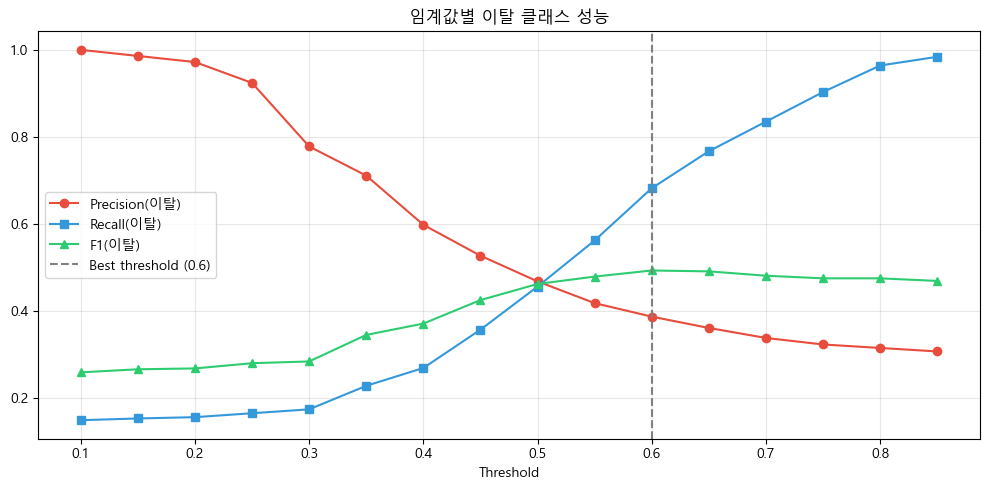

In [13]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.1, 0.9, 0.05)
rows = []
for t in thresholds:
    pred_t = (y_proba4 >= t).astype(int)
    rows.append({
        'threshold':        round(t, 2),
        'Precision(재구매)': round(precision_score(y_te4, pred_t, zero_division=0), 3),
        'Recall(재구매)':   round(recall_score(y_te4, pred_t, zero_division=0), 3),
        'Precision(이탈)':  round(precision_score(y_te4, pred_t, pos_label=0, zero_division=0), 3),
        'Recall(이탈)':    round(recall_score(y_te4, pred_t, pos_label=0, zero_division=0), 3),
        'F1(이탈)':        round(f1_score(y_te4, pred_t, pos_label=0, zero_division=0), 3),
        'Accuracy':        round((pred_t == y_te4).mean(), 3),
    })

thresh_df = pd.DataFrame(rows).set_index('threshold')
print(thresh_df.to_string())

best_t = thresh_df['F1(이탈)'].idxmax()
print(f'\nF1(이탈) 최적 임계값: {best_t}')

best_pred = (y_proba4 >= best_t).astype(int)
print(f'\n=== 임계값 {best_t} 적용 결과 ===')
print(classification_report(y_te4, best_pred, target_names=['이탈(0)','재구매(1)']))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df.index, thresh_df['Precision(이탈)'], 'o-', label='Precision(이탈)', color='#e74c3c')
ax.plot(thresh_df.index, thresh_df['Recall(이탈)'],   's-', label='Recall(이탈)',   color='#3498db')
ax.plot(thresh_df.index, thresh_df['F1(이탈)'],      '^-', label='F1(이탈)',      color='#2ecc71')
ax.axvline(best_t, linestyle='--', color='gray', label=f'Best threshold ({best_t})')
ax.set_xlabel('Threshold')
ax.set_title('임계값별 이탈 클래스 성능')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. v4 SHAP 분석

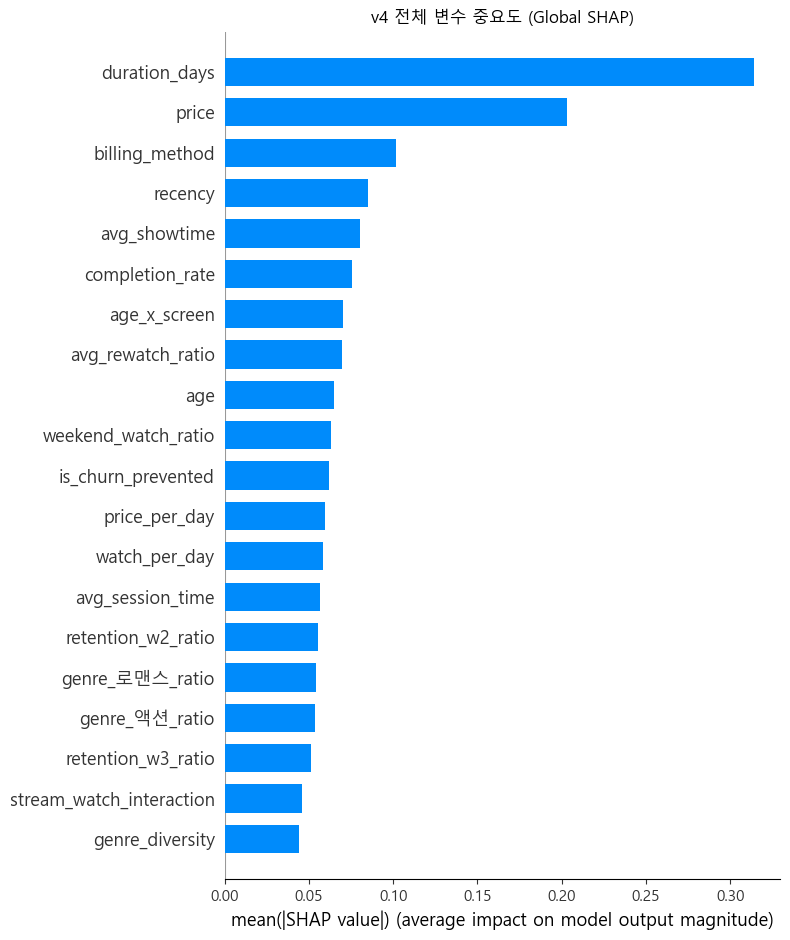

In [14]:
explainer_v4   = shap.TreeExplainer(model_v4)
shap_values_v4 = explainer_v4.shap_values(X_te4)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_v4, X_te4, plot_type="bar", show=False)
plt.title("v4 전체 변수 중요도 (Global SHAP)")
plt.tight_layout()
plt.show()

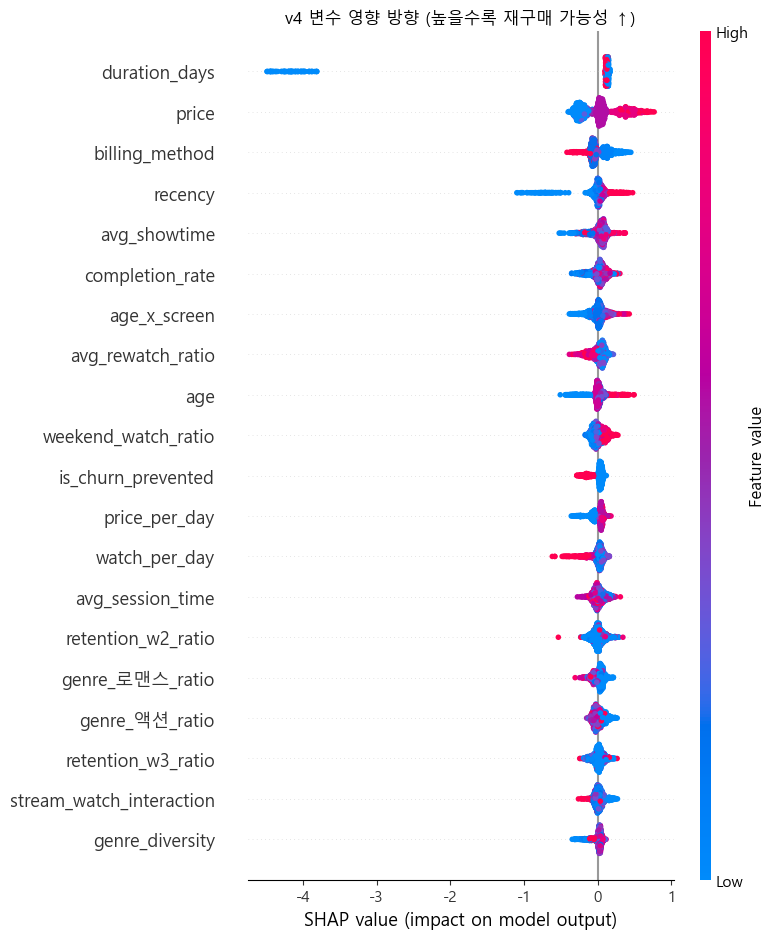

In [15]:
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_values_v4, X_te4, show=False)
plt.title("v4 변수 영향 방향 (높을수록 재구매 가능성 ↑)")
plt.tight_layout()
plt.show()

=== v4 SHAP 중요도 순위 ===
                            변수  SHAP 중요도
1                duration_days  0.313831
2                        price  0.202990
3               billing_method  0.101542
4                      recency  0.084853
5                 avg_showtime  0.080441
6              completion_rate  0.075721
7                 age_x_screen  0.070343
8            avg_rewatch_ratio  0.069578
9                          age  0.064941
10         weekend_watch_ratio  0.063237
11          is_churn_prevented  0.061828
12               price_per_day  0.059662
13               watch_per_day  0.058247
14            avg_session_time  0.056831
15          retention_w2_ratio  0.055087
16             genre_로맨스_ratio  0.054262
17              genre_액션_ratio  0.053551
18          retention_w3_ratio  0.051476
19    stream_watch_interaction  0.045696
20             genre_diversity  0.044005
21                      dur_w1  0.041025
22             genre_스릴러_ratio  0.039433
23             genre_코미디_ratio  0.

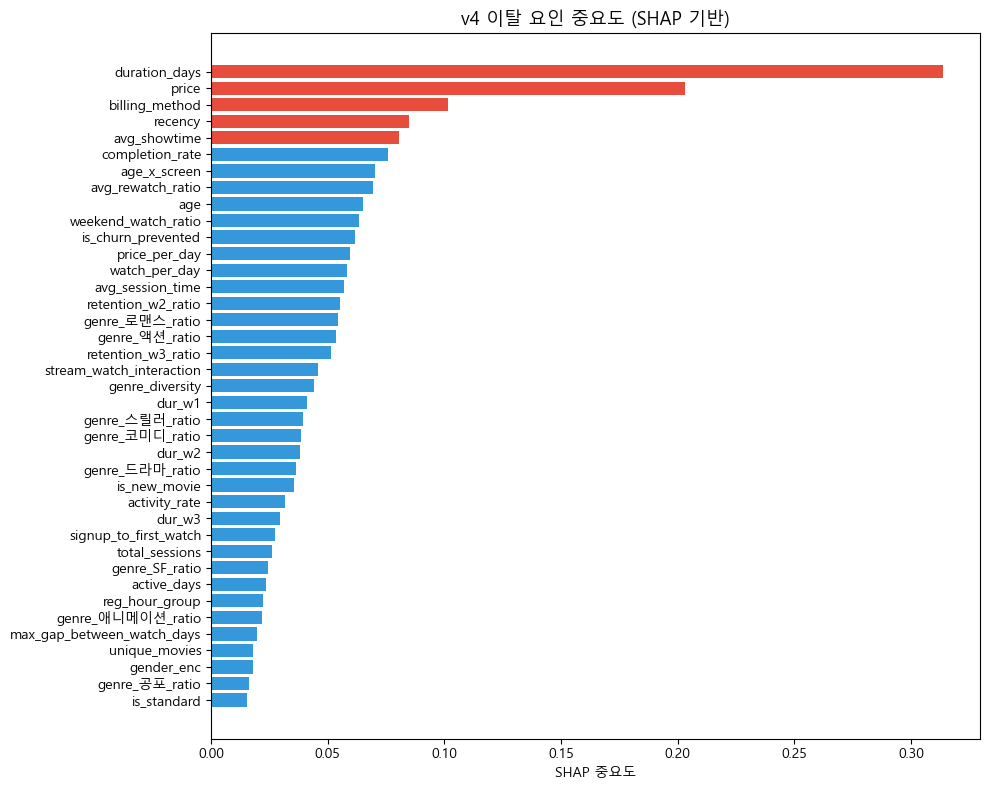

In [16]:
mean_shap_v4 = np.abs(shap_values_v4).mean(axis=0)
shap_df_v4 = pd.DataFrame({"변수": FEATURES_V4, "SHAP 중요도": mean_shap_v4}).sort_values("SHAP 중요도", ascending=False).reset_index(drop=True)
shap_df_v4.index += 1
print("=== v4 SHAP 중요도 순위 ===")
print(shap_df_v4.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if i < 5 else "#3498db" for i in range(len(shap_df_v4))]
ax.barh(shap_df_v4["변수"][::-1], shap_df_v4["SHAP 중요도"][::-1], color=colors[::-1])
ax.set_title("v4 이탈 요인 중요도 (SHAP 기반)", fontsize=13)
ax.set_xlabel("SHAP 중요도")
plt.tight_layout()
plt.show()